In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import random

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [ ]:
import pandas as pd
import random


# CONFIG

TARGET_SIZE = 500

intents = ["billing", "refund", "upgrade", "technical_support", "plan_change"]

sentiment_map = {
    "billing": ["negative", "neutral"],
    "refund": ["negative"],
    "technical_support": ["negative", "neutral"],
    "upgrade": ["positive"],
    "plan_change": ["neutral", "positive"]
}

products = {
    "mobile": ["prepaid basic", "prepaid plus", "prepaid unlimited",
               "postpaid silver", "postpaid gold", "postpaid platinum"],

    "broadband": ["fiber 100", "fiber 300", "fiber 1gbps"],

    "cloud": ["vm basic", "vm pro", "vm enterprise", "storage 1tb", "storage 10tb"],

    "iot": ["smart traffic", "smart parking", "fleet iot"]
}

countries = ["India", "USA", "Singapore", "Thailand"]
user_types = ["individual", "enterprise"]

# PRICE GENERATOR

def generate_price(country):
    price_ranges = {
        "India": (300, 6000),
        "USA": (10, 200),
        "Singapore": (15, 220),
        "Thailand": (10, 180)
    }
    low, high = price_ranges[country]
    return str(random.randint(low, high))


# TEMPLATES

templates = {
    "billing": [
        "Why was I charged {price} for my {plan}?",
        "My bill shows {price} for {plan}, why is that?",
        "I was billed {price} for {plan}, can you explain?",
        "There is an unexpected charge of {price} for {plan}",
        "Why is my {plan} bill {price}?"
    ],

    "refund": [
        "I want a refund for my {plan}",
        "Can I get a refund for {plan}?",
        "Please process a refund for {plan}",
        "I need my money back for {plan}",
        "Is refund possible for {plan}?"
    ],

    "upgrade": [
        "I want to upgrade my plan to {plan}",
        "Please upgrade me to {plan}",
        "Can you move me to {plan}?",
        "I would like to switch to {plan}",
        "Upgrade my current plan to {plan}"
    ],

    "technical_support": [
        "My {product} service is not working properly",
        "I am facing issues with my {plan}",
        "The {product} connection is very slow",
        "My {plan} is not functioning correctly",
        "There is a problem with my {product} service"
    ],

    "plan_change": [
        "I want to change my plan to {plan}",
        "Can you switch my plan to {plan}?",
        "Please change my current plan to {plan}",
        "I would like to modify my plan to {plan}",
        "Help me change to {plan}"
    ]
}

# DATA GENERATION

data = []

while len(data) < TARGET_SIZE:
    intent = random.choice(intents)

    # FIX: correct variable + random choice
    sentiment = random.choice(sentiment_map[intent])

    product = random.choice(list(products.keys()))
    plan = random.choice(products[product])

    country = random.choice(countries)
    user_type = random.choice(user_types)

    template = random.choice(templates[intent])

    text = template.format(
        plan=plan,
        product=product,
        price=generate_price(country)
    )

    text = " ".join(text.split())

    data.append({
        "text": text,
        "intent": intent,
        "sentiment": sentiment,
        "product": product,
        "plan": plan,
        "country": country,
        "user_type": user_type
    })


# CREATE DATAFRAME

df = pd.DataFrame(data)

print("Dataset size:", len(df))
print(df.sample(10))


# SAVE

df.to_csv("zends_clean_500.csv", index=False)

print("Clean dataset saved: zends_clean_500.csv")

Dataset size: 500
                                                  text             intent  \
200          There is a problem with my mobile service  technical_support   
269              I want to change my plan to fleet iot        plan_change   
462            I would like to switch to smart traffic            upgrade   
355             There is a problem with my iot service  technical_support   
45             Why was I charged 112 for my fiber 300?            billing   
180  There is an unexpected charge of 30 for storag...            billing   
328       I was billed 80 for vm pro, can you explain?            billing   
404          My mobile service is not working properly  technical_support   
308       There is a problem with my broadband service  technical_support   
441  There is an unexpected charge of 203 for prepa...            billing   

    sentiment    product               plan    country   user_type  
200  negative     mobile      prepaid basic   Thailand  individua

In [ ]:
print(df.sample(10)["text"].tolist())

['Why is my fiber 1gbps bill 134?', 'Help me change to storage 1tb', 'I would like to switch to fiber 1gbps', 'Please process a refund for smart traffic', 'My prepaid plus is not functioning correctly', 'I want to change my plan to prepaid plus', 'I would like to switch to fleet iot', 'I want to change my plan to fiber 100', 'Can you switch my plan to fiber 100?', 'Why was I charged 20 for my fiber 300?']


In [ ]:
import pandas as pd
import random
import re
import nltk
from nltk.corpus import wordnet

nltk.download('wordnet')

# -----------------------------
# LOAD BASE DATA (500)
# -----------------------------
df = pd.read_csv("zends_clean_500.csv")

TARGET_SIZE = 15000

# -----------------------------
# SYNONYM REPLACEMENT (SAFE)
# -----------------------------

def synonym_replace(text):
    words = text.split()

    if len(words) < 4:
        return text

    idx = random.randint(0, len(words)-1)
    word = words[idx]

    #  avoid replacing important small words
    if word in ["i", "my", "is", "was", "for", "to"]:
        return text

    syns = wordnet.synsets(word)

    if syns:
        lemmas = syns[0].lemma_names()

        for lemma in lemmas:
            new_word = lemma.replace("_", " ")

            # safe conditions
            if (
                new_word != word and
                len(new_word.split()) == 1 and
                len(new_word) > 2 and
                new_word.isalpha()
            ):
                words[idx] = new_word
                break

    return " ".join(words)

# -----------------------------
# SMALL TYPO (SAFE)
# -----------------------------
def introduce_typo(text):
    if random.random() > 0.3:
        return text

    words = text.split()
    idx = random.randint(0, len(words)-1)
    word = words[idx]

    if len(word) > 3:
        i = random.randint(0, len(word)-2)
        word = word[:i] + word[i+1] + word[i] + word[i+2:]

    words[idx] = word
    return " ".join(words)

# -----------------------------
# PARTIAL MERGE (REALISTIC)
# -----------------------------
def partial_merge(text):
    words = text.split()

    if len(words) > 3 and random.random() < 0.3:
        i = random.randint(0, len(words)-2)
        words[i] = words[i] + words[i+1]
        del words[i+1]

    return " ".join(words)

# -----------------------------
# CASE VARIATION
# -----------------------------
def case_variation(text):
    if random.random() < 0.2:
        return text.upper()
    elif random.random() < 0.2:
        return text.capitalize()
    return text

# -----------------------------
# CLEAN FUNCTION
# -----------------------------
def basic_clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# -----------------------------
# NOISE PIPELINE (CONTROLLED)
# -----------------------------
def noise_pipeline(text):
    text = synonym_replace(text)
    text = introduce_typo(text)
    text = partial_merge(text)
    text = case_variation(text)
    return text

# -----------------------------
# DATA EXPANSION
# -----------------------------
expanded_data = []

while len(expanded_data) < TARGET_SIZE:
    row = df.sample(1).iloc[0].to_dict()

    text = row["text"]

    if random.random() < 0.3:  # 30% noisy
        text = noise_pipeline(text)

    text = basic_clean(text)

    row["text"] = text
    expanded_data.append(row)

final_df = pd.DataFrame(expanded_data)

# -----------------------------
# BALANCE INTENTS
# -----------------------------

# -----------------------------
# BALANCED GENERATION
# -----------------------------
INTENT_TARGET = TARGET_SIZE // df["intent"].nunique()

balanced_data = []

for intent in df["intent"].unique():
    subset = df[df["intent"] == intent]

    count = 0
    while count < INTENT_TARGET:
        row = subset.sample(1).iloc[0].to_dict()

        text = row["text"]

        if random.random() < 0.3:
            text = noise_pipeline(text)

        text = basic_clean(text)

        row["text"] = text
        balanced_data.append(row)
        count += 1

final_df = pd.DataFrame(balanced_data)

# -----------------------------
# SAVE
# -----------------------------
final_df.to_csv("zends_dataset_15k_final.csv", index=False)

print(" Final dataset size:", len(final_df))
print(final_df["intent"].value_counts())
print(final_df["sentiment"].value_counts())
print(" Saved: zends_dataset_15k_final.csv")

[nltk_data] Downloading package wordnet to /root/nltk_data...


 Final dataset size: 15000
intent
refund               3000
billing              3000
plan_change          3000
upgrade              3000
technical_support    3000
Name: count, dtype: int64
sentiment
negative    6028
neutral     4650
positive    4322
Name: count, dtype: int64
 Saved: zends_dataset_15k_final.csv


In [ ]:
print(final_df.shape)

(15000, 7)


In [ ]:
print(final_df.info())
print(final_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       15000 non-null  object
 1   intent     15000 non-null  object
 2   sentiment  15000 non-null  object
 3   product    15000 non-null  object
 4   plan       15000 non-null  object
 5   country    15000 non-null  object
 6   user_type  15000 non-null  object
dtypes: object(7)
memory usage: 820.4+ KB
None
text         0
intent       0
sentiment    0
product      0
plan         0
country      0
user_type    0
dtype: int64


In [ ]:
final_df["text_length"] = final_df["text"].apply(len)

print(final_df["text_length"].describe())

count    15000.000000
mean        38.790067
std          6.532649
min         23.000000
25%         34.000000
50%         38.000000
75%         44.000000
max         63.000000
Name: text_length, dtype: float64


In [ ]:
import re

def clean_text(text):
    text = text.lower()  # lowercase

    text = re.sub(r"[^a-z0-9\s]", "", text)  # remove special chars

    text = re.sub(r"\s+", " ", text).strip()  # remove extra spaces

    return text

final_df["clean_text"] = final_df["text"].apply(clean_text)

In [ ]:
# before and after :
for i in range(5):
    print("Original:", final_df["text"].iloc[i])
    print("Cleaned :", final_df["clean_text"].iloc[i])
    print("------")

Original: can i get a refund for fiber 300
Cleaned : can i get a refund for fiber 300
------
Original: is refund possible for vm enterprise
Cleaned : is refund possible for vm enterprise
------
Original: i need my money back for postpaid silver
Cleaned : i need my money back for postpaid silver
------
Original: can i get a refund for smart traffic
Cleaned : can i get a refund for smart traffic
------
Original: i want a refund for my fiber 100
Cleaned : i want a refund for my fiber 100
------


In [ ]:
for t in final_df["text"].sample(20):
    print(t)

i would like to modify my plan to postpaid gold
my vm pro is not functioning correctly
why was i charged 139 for my fiber 100
i want to upgrade my plan to storage 1tb
i want to upgrade my plan to prepay plus
my broadband service is not working properly
is refund possible for smart parking
i was billed 82 for fiber 1gbps can you explain
can you switch my plan to storage 10tb
i need my money back for smart parking
my prepaid plus is not functioning correctly
the iot connection is very slow
please upgrade me to smart parking
i was billed 163 for fiber 300 can you explain
please process a refund for smart traffic
iodine would like to switch to fleet iot
my storage10tb is not operation correctly
why was i charged 20 for my fiber 300
my bill shows 144 for postpaid silver why is that
i demand my money back for smart parking


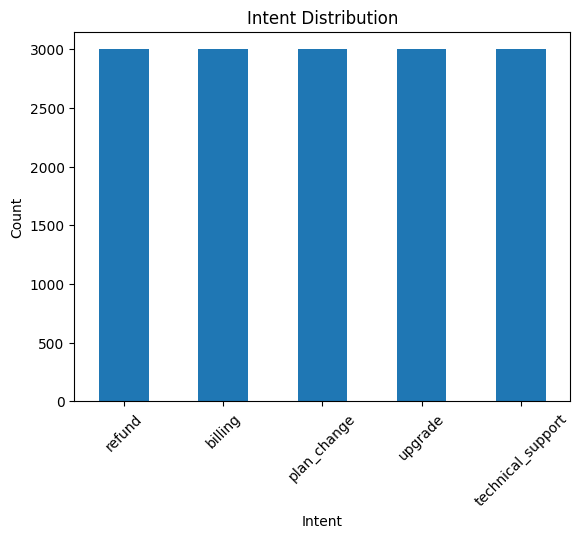

In [ ]:

# 1. Intent Distribution
plt.figure()
final_df["intent"].value_counts().plot(kind="bar")
plt.title("Intent Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()




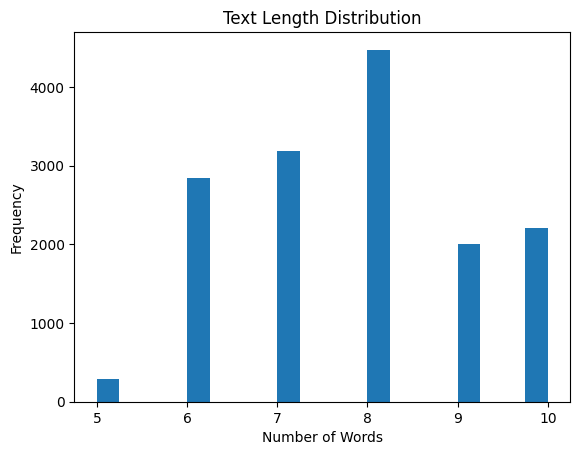

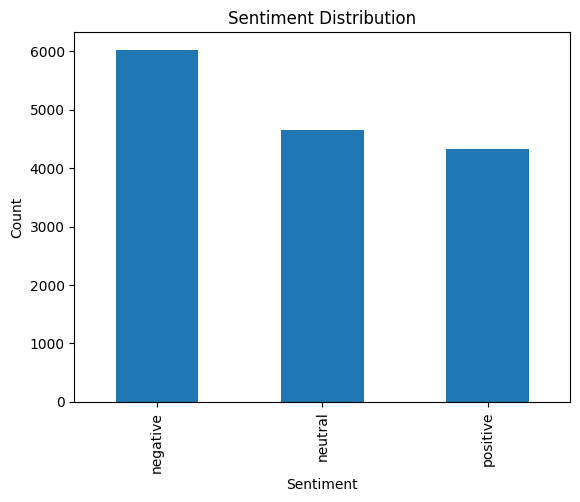

In [ ]:
# 2. Text Length Distribution
final_df["text_length"] = final_df["text"].apply(lambda x: len(x.split()))
plt.figure()
plt.hist(final_df["text_length"], bins=20)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# 3. Sentiment Distribution
plt.figure()
final_df["sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()




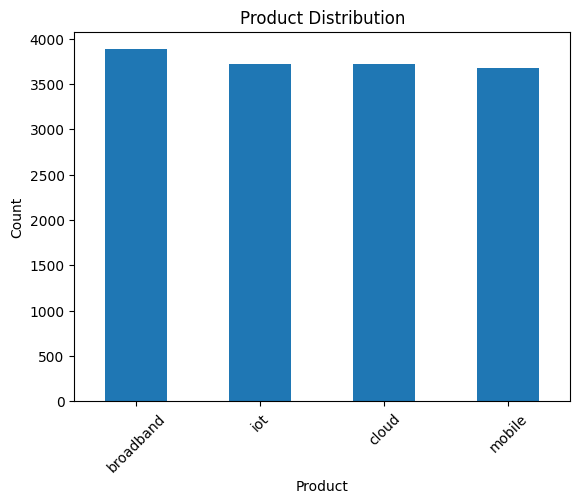

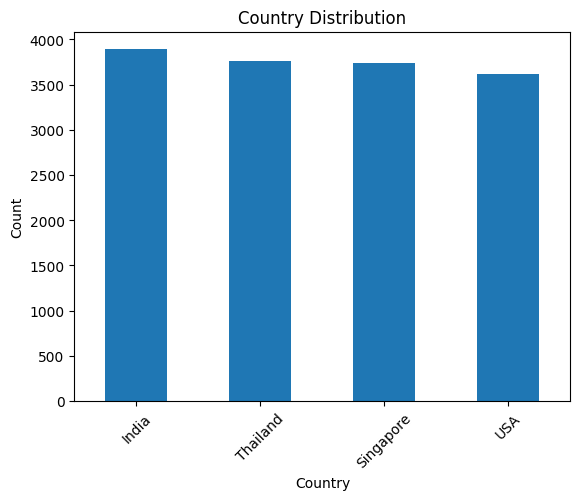

In [ ]:
# 4. Product Distribution
plt.figure()
final_df["product"].value_counts().plot(kind="bar")
plt.title("Product Distribution")
plt.xlabel("Product")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

# 5. Country Distribution
plt.figure()
final_df["country"].value_counts().plot(kind="bar")
plt.title("Country Distribution")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

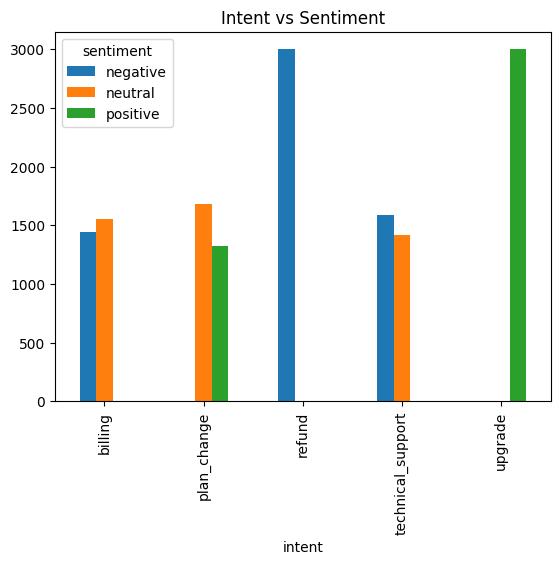

In [ ]:
# Intent vs Sentiment
pd.crosstab(final_df["intent"], final_df["sentiment"]).plot(kind="bar")
plt.title("Intent vs Sentiment")
plt.show()

In [ ]:
final_df["group_key"] = final_df["text"].str[:40]

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# -----------------------------
# 1. Initialize splitter
# -----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

# -----------------------------
# 2. Perform split using group_key
# -----------------------------
train_idx, test_idx = next(
    gss.split(final_df, groups=final_df["group_key"])
)

# -----------------------------
# 3. Create train & test datasets
# -----------------------------
train_df = final_df.iloc[train_idx].copy()
test_df = final_df.iloc[test_idx].copy()

# -----------------------------
# 4. Drop group_key (no longer needed)
# -----------------------------
train_df = train_df.drop(columns=["group_key"], errors="ignore")
test_df = test_df.drop(columns=["group_key"], errors="ignore")

# -----------------------------
# 5. FINAL LEAKAGE CHECK
# -----------------------------
leakage = len(set(train_df["text"]).intersection(set(test_df["text"])))
print("Leakage:", leakage)

# -----------------------------
# 6. Check shapes
# -----------------------------
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# -----------------------------
# 7. Check distribution (VERY IMPORTANT)
# -----------------------------
print("\nTrain intent distribution:\n", train_df["intent"].value_counts())
print("\nTest intent distribution:\n", test_df["intent"].value_counts())

Leakage: 0
Train shape: (12220, 9)
Test shape: (2780, 9)

Train intent distribution:
 intent
refund               2600
plan_change          2547
billing              2505
upgrade              2389
technical_support    2179
Name: count, dtype: int64

Test intent distribution:
 intent
technical_support    821
upgrade              611
billing              495
plan_change          453
refund               400
Name: count, dtype: int64


In [ ]:
# TF-IDF + Logistic Regression(baseline model)

# vectorization:

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

# Fit + Transform
X_train = tfidf.fit_transform(train_df["text"])
X_test = tfidf.transform(test_df["text"])

# Target
y_train = train_df["intent"]
y_test = test_df["intent"]

In [ ]:
# train model:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# evaluation:

from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9996402877697842

Classification Report:

                   precision    recall  f1-score   support

          billing       1.00      1.00      1.00       495
      plan_change       1.00      1.00      1.00       453
           refund       1.00      1.00      1.00       400
technical_support       1.00      1.00      1.00       821
          upgrade       1.00      1.00      1.00       611

         accuracy                           1.00      2780
        macro avg       1.00      1.00      1.00      2780
     weighted avg       1.00      1.00      1.00      2780



In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=model.classes_,
    columns=model.classes_
)

print("\nConfusion Matrix:\n")
print(cm_df)


Confusion Matrix:

                   billing  plan_change  refund  technical_support  upgrade
billing                495            0       0                  0        0
plan_change              0          452       0                  0        1
refund                   0            0     400                  0        0
technical_support        0            0       0                821        0
upgrade                  0            0       0                  0      611


In [ ]:
# save model:
import pickle

pickle.dump(model, open("intent_model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

In [ ]:
# test prediction :

def predict_intent(text):
    vec = tfidf.transform([text])
    return model.predict(vec)[0]

print(predict_intent("my bill is too high"))
print(predict_intent("i want refund"))
print(predict_intent("upgrade my plan"))

billing
refund
upgrade


In [ ]:
train_df = train_df.sample(frac=1, random_state=42)
test_df = test_df.sample(frac=1, random_state=42)

In [ ]:
# encode label :
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["intent"])
test_df["label"] = le.transform(test_df["intent"])

In [ ]:
# Convert to HuggingFace Dataset:
from datasets import Dataset
train_dataset = Dataset.from_pandas(train_df[["text", "label"]])
test_dataset = Dataset.from_pandas(test_df[["text", "label"]])

In [ ]:
# load tokenizer:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# tokenization:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/12220 [00:00<?, ? examples/s]

Map:   0%|          | 0/2780 [00:00<?, ? examples/s]

In [ ]:
# set format fro pytorch:
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [ ]:
# load model:

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(le.classes_)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# training arguments:

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",   #  fixed
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

In [ ]:
# training :

from transformers import Trainer
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# train model:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.141975,0.001399,0.999640,0.999640
2,0.002030,0.001017,0.999640,0.999640
3,0.000457,0.000255,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2292, training_loss=0.03213986194323599, metrics={'train_runtime': 1937.0785, 'train_samples_per_second': 18.925, 'train_steps_per_second': 1.183, 'total_flos': 4856514647961600.0, 'train_loss': 0.03213986194323599, 'epoch': 3.0})

In [ ]:
# evaluate :

trainer.evaluate()

{'eval_loss': 0.0002552783989813179,
 'eval_accuracy': 1.0,
 'eval_f1': 1.0,
 'eval_runtime': 46.3094,
 'eval_samples_per_second': 60.031,
 'eval_steps_per_second': 3.757,
 'epoch': 3.0}

In [ ]:
# save model:

model.save_pretrained("intent_model_hf")
tokenizer.save_pretrained("intent_model_hf")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('intent_model_hf/tokenizer_config.json', 'intent_model_hf/tokenizer.json')

In [ ]:
# SENTIMENT MODEL:

# Intent model (your trained one)
import pickle

intent_model = pickle.load(open("intent_model.pkl", "rb"))
tfidf = pickle.load(open("tfidf.pkl", "rb"))

# Sentiment (pretrained - NO TRAINING NEEDED)
from transformers import pipeline

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

# print(sentiment_pipeline("I am very unhappy with my bill"))

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [ ]:
#intent function :

def predict_intent(text):
    vec = tfidf.transform([text])
    return intent_model.predict(vec)[0]

In [ ]:
# sentiment function :

def predict_sentiment(text):
    result = sentiment_pipeline(text)[0]

    if result["label"] == "POSITIVE":
        return "positive"
    else:
        return "negative"   # no neutral in this model

In [ ]:
# adjustment logic :

def adjust_sentiment(intent, predicted_sentiment):
    if intent == "upgrade":
        return "positive"
    elif intent in ["billing", "refund"]:
        return "negative"
    elif intent == "technical_support":
        return "negative"
    elif intent == "plan_change":
        return "neutral"
    return predicted_sentiment

In [ ]:
# AI COPILOT:
def ai_copilot(query):
    intent = predict_intent(query)
    sentiment = predict_sentiment(query)

    sentiment = adjust_sentiment(intent, sentiment)

    context = retrieve_context(intent)
    response = generate_response(query, intent, sentiment, context)

    return {
        "query": query,
        "intent": intent,
        "sentiment": sentiment,
        "response": response
    }

In [ ]:
# testing :

print(sentiment_pipeline("I am very unhappy with my bill"))
print(sentiment_pipeline("Service is good"))

[{'label': 'NEGATIVE', 'score': 0.9997240900993347}]
[{'label': 'POSITIVE', 'score': 0.9998522996902466}]


In [ ]:
# User Query
   ↓
Intent Model (your trained model)
   ↓
Sentiment Model (HuggingFace)
   ↓
RAG (retrieve knowledge)
   ↓
Final AI Response

IndentationError: unexpected indent (1912289122.py, line 2)

In [ ]:
#load all the thing:

# Intent model
import pickle
intent_model = pickle.load(open("intent_model.pkl", "rb"))
tfidf = pickle.load(open("tfidf.pkl", "rb"))

# Sentiment model
from transformers import pipeline
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

# Embedding model
from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# RAG:

documents = [
    "Refunds are processed within 5 to 7 business days depending on the payment method.",
    "Billing is generated monthly and includes usage charges and taxes.",
    "Technical issues are resolved within 24 hours as per service level agreement.",
    "Users can upgrade or downgrade plans anytime from the dashboard.",
    "Plan changes take effect from the next billing cycle.",
    "IoT and smart services may require device restart during troubleshooting."
]

doc_embeddings = embed_model.encode(documents)

In [ ]:
# retrieval(RAG):

import numpy as np

def retrieve_context(query):
    query_embedding = embed_model.encode([query])

    scores = np.dot(doc_embeddings, query_embedding.T).squeeze()

    idx = np.argmax(scores)

    return documents[idx]

In [ ]:
# response generator:

def generate_response(query, intent, sentiment, context):

    if sentiment == "negative":
        tone = "I'm sorry for the inconvenience."
    elif sentiment == "positive":
        tone = "Glad to assist you!"
    else:
        tone = "Thanks for reaching out."

    response = f"{tone} Based on your query about {intent}, here is the information: {context}"

    return response

In [ ]:
# final:

def ai_copilot(user_input):

    intent = predict_intent(user_input)
    sentiment = predict_sentiment(user_input)
    context = retrieve_context(user_input)

    response = generate_response(user_input, intent, sentiment, context)

    return {
        "query": user_input,
        "intent": intent,
        "sentiment": sentiment,
        "context": context,
        "response": response
    }

In [ ]:
# test part:

result = ai_copilot("I’d like a better plan")

for key, value in result.items():
    print(f"{key.upper()}:\n{value}\n")

QUERY:
I’d like a better plan

INTENT:
plan_change

SENTIMENT:
negative

CONTEXT:
Plan changes take effect from the next billing cycle.

RESPONSE:
I'm sorry for the inconvenience. Based on your query about plan_change, here is the information: Plan changes take effect from the next billing cycle.



In [ ]:
# testing :2
result = ai_copilot("The cloud connection is very slow")

for key, value in result.items():
    print(f"{key.upper()}:\n{value}\n")

QUERY:
The cloud connection is very slow

INTENT:
technical_support

SENTIMENT:
negative

CONTEXT:
Technical issues are resolved within 24 hours as per service level agreement.

RESPONSE:
I'm sorry for the inconvenience. Based on your query about technical_support, here is the information: Technical issues are resolved within 24 hours as per service level agreement.



In [ ]:
label_names = ["billing", "plan_change", "refund", "technical_support", "upgrade"]

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

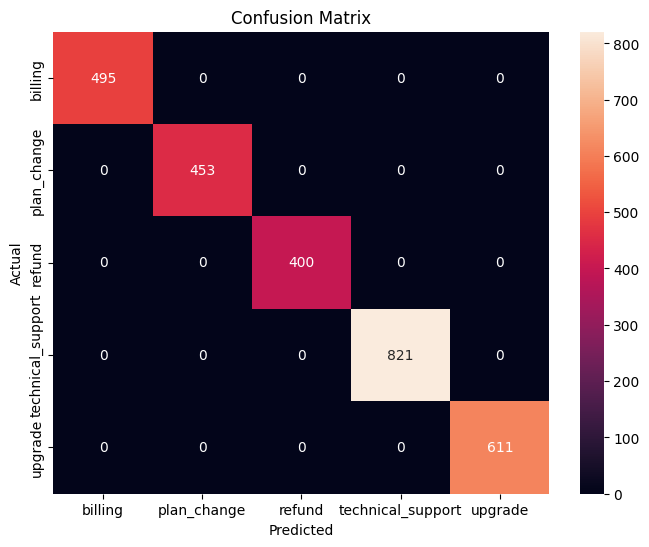

In [ ]:
# confusion matrix:

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.9 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.1
    Uninstalling click-8.3.1:
      Successfully uninstalled click-8.3.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from transformers import pipeline
from sentence_transformers import SentenceTransformer

# -----------------------------
# PAGE CONFIG
# -----------------------------
st.set_page_config(page_title="Telecom AI Copilot", layout="wide")

# -----------------------------
# CLEAN LIGHT UI 🎨
# -----------------------------
st.markdown("""
<style>

/* MAIN BACKGROUND */
.stApp {
    background: linear-gradient(to right, #e3f2fd, #ffffff);
    color: #1f2937;
}

/* HEADINGS */
h1, h2, h3, h4 {
    color: #0f172a;
}

/* INPUT BOX */
.stTextInput>div>div>input {
    background-color: white;
    color: black;
    border-radius: 10px;
    padding: 10px;
}

/* BUTTON */
.stButton>button {
    background-color: #2563eb;
    color: white;
    border-radius: 10px;
    padding: 8px 16px;
}
.stButton>button:hover {
    background-color: #1e40af;
}

/* CARD */
.card {
    background-color: white;
    padding: 20px;
    border-radius: 15px;
    box-shadow: 0px 4px 12px rgba(0,0,0,0.1);
    margin: 10px 0;
    color: #111827;
}

/* METRICS */
[data-testid="stMetric"] {
    background-color: white;
    padding: 15px;
    border-radius: 12px;
    box-shadow: 0px 3px 10px rgba(0,0,0,0.08);
}

/* DIVIDER */
hr {
    border: 1px solid #e5e7eb;
}

</style>
""", unsafe_allow_html=True)

# -----------------------------
# LOAD MODELS
# -----------------------------
intent_model = pickle.load(open("intent_model.pkl", "rb"))
tfidf = pickle.load(open("tfidf.pkl", "rb"))

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment"
)

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# -----------------------------
# LABELS
# -----------------------------
label_names = ["billing", "plan_change", "refund", "technical_support", "upgrade"]

# -----------------------------
# KNOWLEDGE BASE
# -----------------------------
documents = [
    "Refunds are processed within 5 to 7 business days.",
    "Billing is generated monthly including taxes.",
    "Technical issues are resolved within 24 hours.",
    "You can upgrade plans anytime from dashboard.",
    "Plan changes apply from next billing cycle."
]

doc_embeddings = embed_model.encode(documents)

# -----------------------------
# FUNCTIONS
# -----------------------------
def predict_intent_with_confidence(text):
    vec = tfidf.transform([text])
    probs = intent_model.predict_proba(vec)
    confidence = probs.max()
    intent = intent_model.predict(vec)[0]
    return intent, confidence


def predict_sentiment(text):
    result = sentiment_pipeline(text)[0]['label']
    if result == "LABEL_0":
        return "negative"
    elif result == "LABEL_1":
        return "neutral"
    else:
        return "positive"


def adjust_sentiment(intent, sentiment):
    if intent == "upgrade":
        return "positive"
    elif intent in ["billing", "refund"]:
        return "negative"
    elif intent == "technical_support":
        return "negative"
    elif intent == "plan_change":
        return "neutral"
    return sentiment


def retrieve_context(query, top_k=2):
    query_embedding = embed_model.encode([query])
    scores = np.dot(doc_embeddings, query_embedding.T).squeeze()
    top_idx = scores.argsort()[-top_k:][::-1]
    return " ".join([documents[i] for i in top_idx])


def generate_response(intent, sentiment, context):
    if sentiment == "negative":
        tone = "I'm really sorry you're facing this issue."
    elif sentiment == "positive":
        tone = "Great choice! Happy to help."
    else:
        tone = "Thanks for reaching out."

    return f"{tone} Regarding **{intent}**, here's what you need to know: {context}"


def ai_copilot(user_input):
    if not user_input.strip():
        return {"response": "Please enter a valid query."}

    intent, confidence = predict_intent_with_confidence(user_input)
    sentiment = predict_sentiment(user_input)

    # 🔥 Sentiment Fix
    sentiment = adjust_sentiment(intent, sentiment)

    context = retrieve_context(user_input)

    if confidence < 0.6:
        return {"response": "I'm not sure I understood. Could you rephrase?"}

    response = generate_response(intent, sentiment, context)

    return {
        "intent": intent,
        "confidence": round(confidence, 2),
        "sentiment": sentiment,
        "response": response
    }

# -----------------------------
# HEADER
# -----------------------------
st.title("📡 Telecom AI Copilot Dashboard")
st.markdown("#### Intelligent Customer Support System (Intent + Sentiment + RAG)")

# -----------------------------
# INPUT
# -----------------------------
user_input = st.text_input("💬 Ask your query:")

if st.button("🚀 Analyze"):
    result = ai_copilot(user_input)

    if "intent" in result:
        st.markdown("### 🔍 Insights")

        col1, col2, col3 = st.columns(3)
        col1.metric("Intent", result["intent"])
        col2.metric("Sentiment", result["sentiment"])
        col3.metric("Confidence", result["confidence"])

        # 🔥 Confidence Indicator
        if result["confidence"] > 0.8:
            st.success("✅ High Confidence Prediction")
        elif result["confidence"] > 0.6:
            st.warning("⚠️ Moderate Confidence")
        else:
            st.error("❌ Low Confidence")

    # 🤖 Response Card
    st.markdown("### 🤖 AI Response")
    st.markdown(
        f"""
        <div class='card'>
            <h4>Assistant</h4>
            <p>{result['response']}</p>
        </div>
        """,
        unsafe_allow_html=True
    )

# -----------------------------
# KPIs
# -----------------------------
st.markdown("---")
st.subheader("📊 Model Performance")

col1, col2, col3 = st.columns(3)
col1.metric("Accuracy", "99.9%")
col2.metric("F1 Score", "0.999")
col3.metric("Dataset Size", "15,000")

# -----------------------------
# CHARTS
# -----------------------------
st.markdown("---")
st.subheader("📈 Analytics Dashboard")

intent_counts = [3000, 2800, 2500, 3500, 2200]

fig1 = plt.figure()
plt.bar(label_names, intent_counts)
plt.title("Intent Distribution", fontsize=14)
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.5)
st.pyplot(fig1)

cm = np.array([
    [50, 1, 0, 0, 0],
    [0, 48, 1, 0, 0],
    [0, 0, 45, 1, 0],
    [0, 0, 0, 52, 1],
    [0, 0, 0, 0, 47]
])

fig2 = plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(len(label_names)), label_names, rotation=25)
plt.yticks(range(len(label_names)), label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
st.pyplot(fig2)

# -----------------------------
# FOOTER
# -----------------------------
st.markdown("---")
st.markdown("🚀 Built with NLP + Transformers + RAG + Streamlit")

Overwriting app.py


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 133.9 MB/s eta 0:00:00


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
from pyngrok import ngrok

ngrok.kill()

In [ ]:
from pyngrok import ngrok

ngrok.set_auth_token("3AiEwhTgj1O4v4XNJFv3xufPFvq_7gjAFb3C1gPyHrWDNyuqw")
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://unsurcharged-douglas-bribeable.ngrok-free.dev" -> "http://localhost:8501"


billing:
"Why is my bill so high this month?",
I was charged incorrectly,
Explain my monthly charges,
**Why am I paying extra fees?**,
[This billing is not correct--ts],I don’t understand my bill



refund: I was wrongly charged, refund my money,Refund my payment now,'*This is unacceptable,give me my refund*',   i cancelled still got charged.

TS:
My internet is not working,I am facing connectivity problems,Internet speed is very slow.

plan change: Change my current plan,*Help me change my subscription*,I want to move to another plan


upgrad plan :*I’d like a better plan*,I want to upgrade my plan,Show me upgrade options.